In [1]:
# These are our tools. Think of "import" like opening a toolbox.
import pandas as pd           # for working with tables of data
import numpy as np            # for math operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns         # prettier charts, built on matplotlib
import warnings
warnings.filterwarnings('ignore')  # hides annoying non-critical warnings

# This line makes charts appear inside the notebook (not in a separate window)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# pd.read_csv() reads a CSV file and turns it into a "DataFrame"
# A DataFrame is just a table — like an Excel spreadsheet in Python
df = pd.read_csv('../data/cs-training.csv', index_col=0)

# .shape tells you (number of rows, number of columns)
print(f"Dataset shape: {df.shape}")
print(f"That's {df.shape[0]:,} loan applicants and {df.shape[1]} features each")

Dataset shape: (150000, 11)
That's 150,000 loan applicants and 11 features each


In [3]:
# .head() shows the first 5 rows — your first look at real data
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# .info() tells you: column names, data types, and how many non-null values
# "null" means missing — no value recorded for that person
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [5]:
# .describe() gives you min, max, average, etc. for every column
# This is how you spot weird values fast
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


=== TARGET VARIABLE BREAKDOWN ===
Paid fine (0):   139,974 people  (93.3%)
Defaulted (1):   10,026 people  (6.7%)


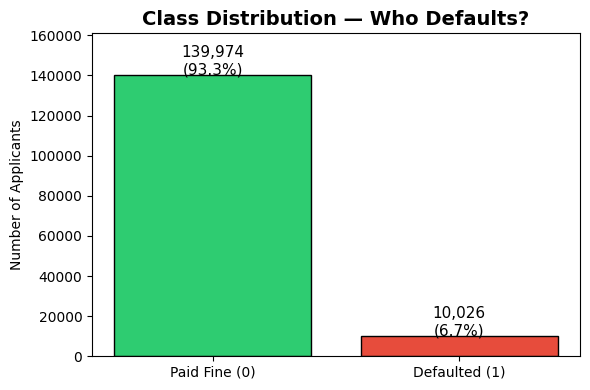

Chart saved!


In [6]:
# "SeriousDlqin2yrs" is our TARGET — what we're trying to predict
# 1 = this person defaulted on their loan
# 0 = this person paid fine
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("=== TARGET VARIABLE BREAKDOWN ===")
print(f"Paid fine (0):   {target_counts[0]:,} people  ({target_pct[0]:.1f}%)")
print(f"Defaulted (1):   {target_counts[1]:,} people  ({target_pct[1]:.1f}%)")

# Visualise it
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Paid Fine (0)', 'Defaulted (1)'], 
               target_counts.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black')

# Add count labels on bars
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11)

ax.set_title('Class Distribution — Who Defaults?', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Applicants')
ax.set_ylim(0, target_counts[0] * 1.15)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

=== MISSING VALUES ===
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


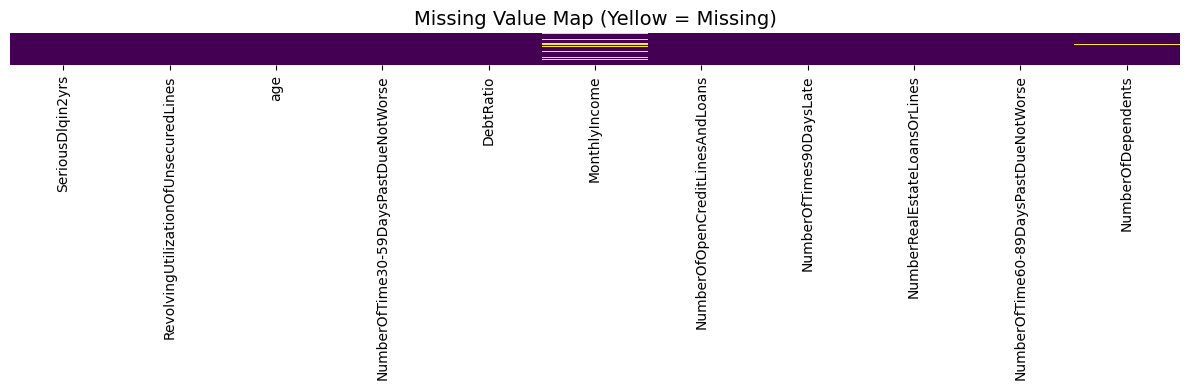

In [7]:
# Missing data = gaps in the table = problems for ML models
# Models can't handle blanks — we need to fix them later
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("=== MISSING VALUES ===")
print(missing_df[missing_df['Missing Count'] > 0])

# Heatmap of missing values
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), 
            yticklabels=False, 
            cbar=False, 
            cmap='viridis')
plt.title('Missing Value Map (Yellow = Missing)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/missing_values.png', dpi=150)
plt.show()

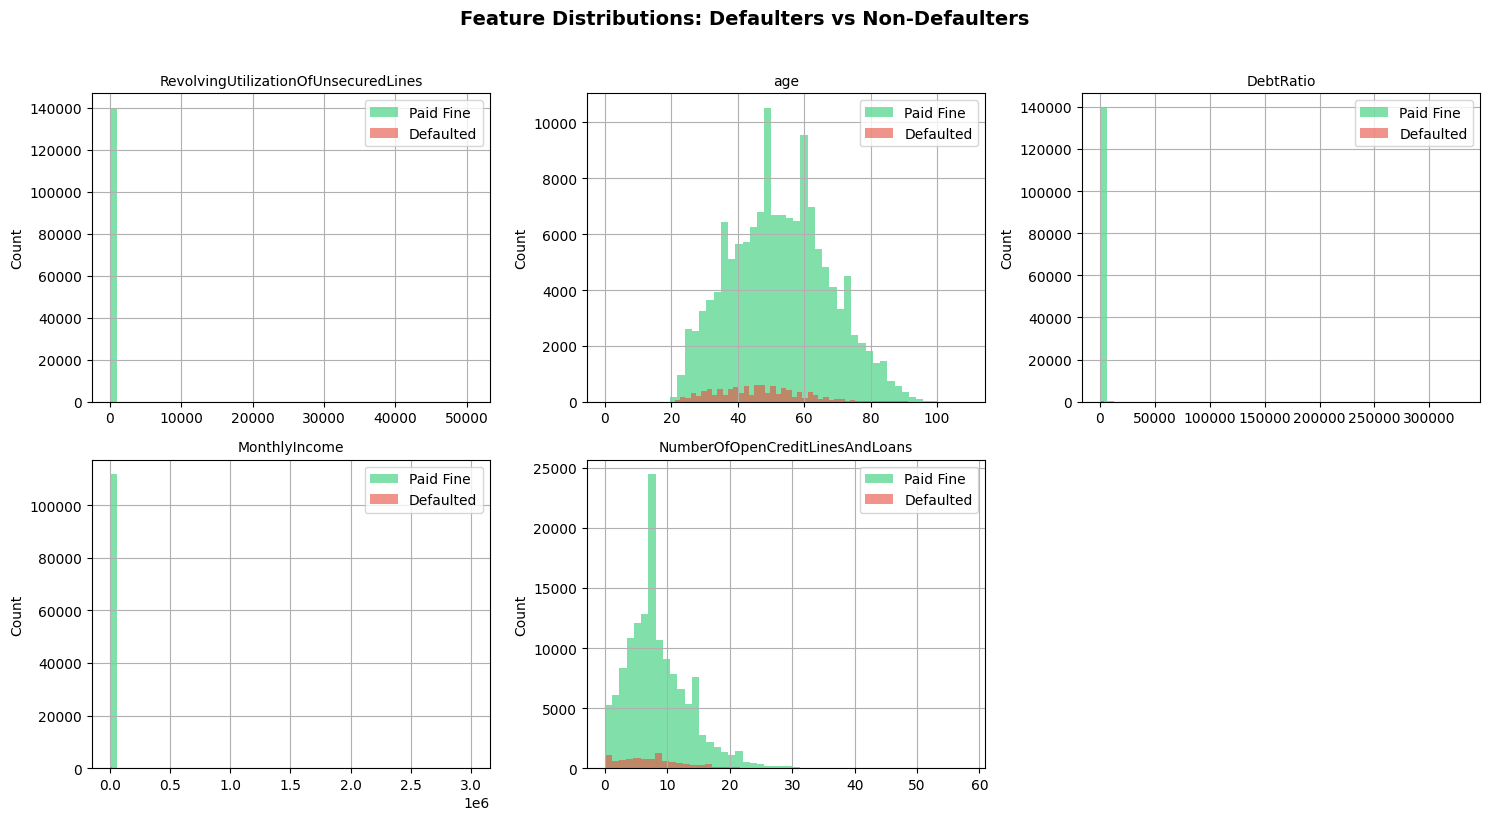

In [8]:
# This is the key question: do defaulters LOOK different from non-defaulters?
# If yes, our model can learn to tell them apart

features_to_plot = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Plot defaulters vs non-defaulters on the same chart
    df[df['SeriousDlqin2yrs'] == 0][feature].hist(
        bins=50, alpha=0.6, label='Paid Fine', color='#2ecc71', ax=axes[i])
    df[df['SeriousDlqin2yrs'] == 1][feature].hist(
        bins=50, alpha=0.6, label='Defaulted', color='#e74c3c', ax=axes[i])
    
    axes[i].set_title(feature, fontsize=10)
    axes[i].legend()
    axes[i].set_ylabel('Count')

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions: Defaulters vs Non-Defaulters', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150)
plt.show()

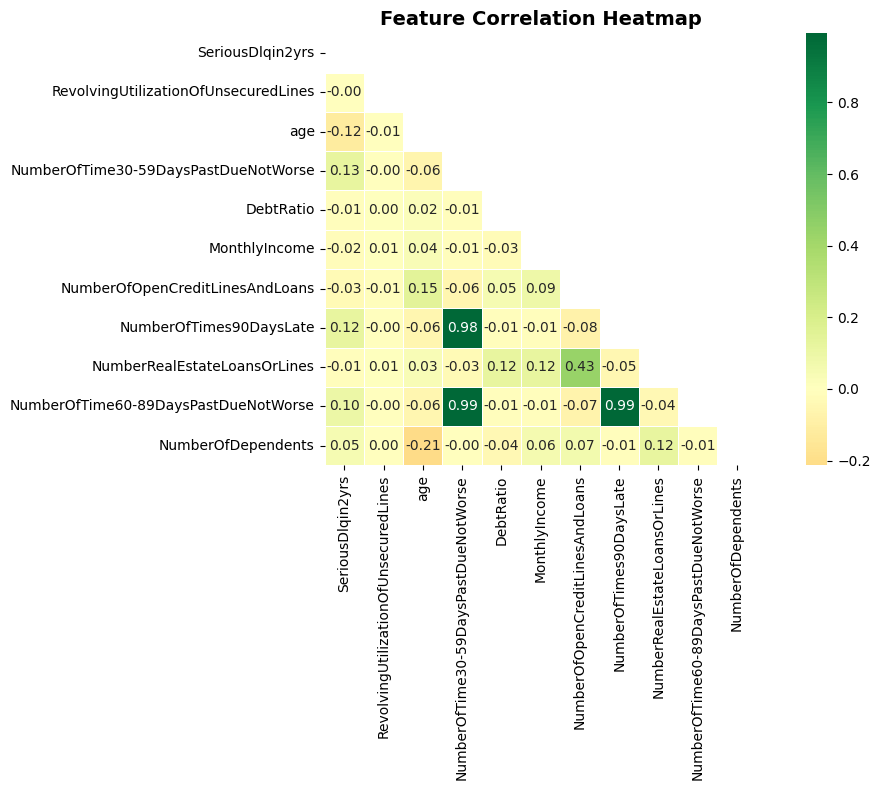

In [9]:
# Correlation = how much two things move together
# +1 = perfectly together, -1 = perfectly opposite, 0 = no relationship
# We use this to find: 
#   (a) which features relate to default (useful!)
#   (b) which features are copies of each other (redundant, drop one)

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Create a mask so we only show the bottom triangle (it's symmetric)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,        # show numbers in each cell
            fmt='.2f',         # 2 decimal places
            cmap='RdYlGn',     # red=negative, yellow=zero, green=positive
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"\n📊 Dataset: {df.shape[0]:,} applicants, {df.shape[1]} features")
print(f"\n⚠️  Class Imbalance:")
print(f"   Only {target_pct[1]:.1f}% of applicants defaulted")
print(f"   This means a model that ALWAYS predicts 'no default'")
print(f"   would be {target_pct[0]:.1f}% accurate — but completely useless!")
print(f"\n🕳️  Missing Values:")
for col in missing_df[missing_df['Missing Count'] > 0].index:
    print(f"   {col}: {missing_df.loc[col, 'Missing %']:.1f}% missing")
print(f"\n✅ Next step: Feature Engineering — clean and prepare this data for ML")

EDA SUMMARY

📊 Dataset: 150,000 applicants, 11 features

⚠️  Class Imbalance:
   Only 6.7% of applicants defaulted
   This means a model that ALWAYS predicts 'no default'
   would be 93.3% accurate — but completely useless!

🕳️  Missing Values:
   MonthlyIncome: 19.8% missing
   NumberOfDependents: 2.6% missing

✅ Next step: Feature Engineering — clean and prepare this data for ML
